# Universidad de Buenos Aires

# Aprendizaje Profundo - TP3

# Cohorte 24 - 2do bimestre 2026


Este tercer y último TP se debe entregar hasta las **23:59hs del viernes 19 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar los contenidos vistos en clase y otra bibliografía que consideren que les haga falta. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP3 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/56R6couXZBPDZzfs5)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**

- Se entregará 1 solo colab para este TP3.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP3-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- Los resultados, cómo el código, los gráficos y las explicaciones deben quedar guardados y visualizables en el correspondiente notebook.
- Prestar atención a las consignas, responder las preguntas cuando corresponda.
- Solo se revisarán los trabajos que hayan sido enviados por el forms.


# **CLASIFICADOR DE EMOCIONES**


El objetivo de este trabajo es construir una red neuronal convolucional (CNN) utilizando Pytorch, capaz de clasificar emociones humanas a partir de imágenes faciales. El clasificador deberá identificar una de las 7 emociones básicas: alegría, tristeza, enojo, miedo, sorpresa, disgusto y seriedad. El dataset se encuentra en este link: https://drive.google.com/file/d/1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT/view?usp=sharing


Les recomiendo usar el siguiente código para poder obtener las imágenes fácilmente desde ese link. Pero son libres de descargar las imágenes como mejor les parezca.


In [30]:
import gdown
import zipfile
import os

url = "https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT"
output = "archivo.zip"

gdown.download(url, output, quiet=False)

destino = "datos_zip"
os.makedirs(destino, exist_ok=True)

with zipfile.ZipFile(output, "r") as zip_ref:
    zip_ref.extractall(destino)

DATASET_ROOT_TRAIN = "datos_zip/dataset_emociones/train"
DATASET_ROOT_VAL = "datos_zip/dataset_emociones/validation"

Downloading...
From (original): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT
From (redirected): https://drive.google.com/uc?id=1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT&confirm=t&uuid=d45ebe49-2b55-4982-b455-f64e3f7615ca
To: /Users/alejandrovalle/Desktop/Posgrado/CEIA/3er_bimestre/DeepLearning/deep_learning/archivo.zip
100%|██████████| 40.0M/40.0M [00:02<00:00, 15.4MB/s]


## Configuración del entorno

Importamos las librerías necesarias, fijamos una **semilla** para que los resultados sean reproducibles y detectamos si hay **GPU** disponible (en Colab: `Entorno de ejecución -> Cambiar tipo de entorno de ejecución -> GPU`).

> En Google Colab `torch` y `torchvision` ya vienen instalados, por lo que no hace falta instalarlos.


In [31]:
# === Librerias ===
import os, random, time, copy, collections
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
)

# seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# set device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Dispositivo:", device)
print("torch:", torch.__version__, "| torchvision:", torchvision.__version__)

Dispositivo: mps
torch: 2.12.0 | torchvision: 0.27.0


## 1. Preprocesamiento de Datos (2 puntos)

Antes de entrenar el modelo, se debe analizar qué tipo de preprocesamiento se debe aplicar a las imágenes. Para esto, se puede considerar uno o más aspectos como:

- Tamaño
- Relación de aspecto
- Color o escala de grises
- Cambio de dimensionalidad
- Normalización
- Balanceo de datos
- Data augmentation
- etc.

Sean criteriosos y elijan solo las técnicas que consideren pertinentes para este caso de uso en específico.

Recomendación: usar `torchvision.transforms` para facilitar el preprocesamiento. Lean su documentación si tienen dudas: https://docs.pytorch.org/vision/0.14/transforms.html


### EDA

Antes de decidir el preprocesamiento, observamos las características reales del dataset:

- Images por clase
- Tamaño y color de las imagenes
- Visualización de ejemplos en cada emoción


Clases (orden alfabetico = orden interno de ImageFolder):
['alegria', 'disgusto', 'enojo', 'miedo', 'seriedad', 'sorpresa', 'tristeza']

Clase           Train      Val
alegria          4772     1185
disgusto          717      160
enojo             705      162
miedo             281       74
seriedad         2524      680
sorpresa         1290      329
tristeza         1982      478
TOTAL           12271     3068


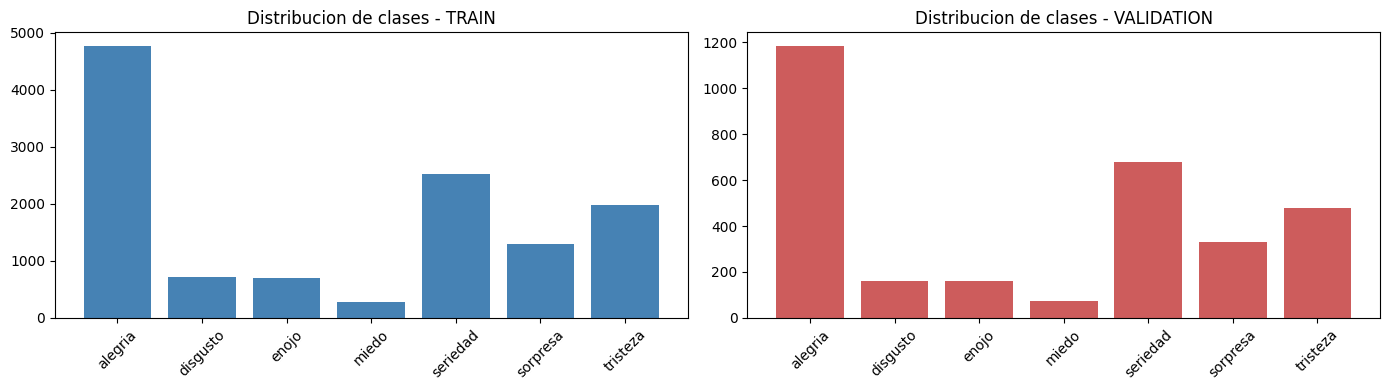

Desbalance (mayoritaria / minoritaria) en train: 17.0 : 1


In [32]:
# Conteo de imagenes por clase en cada split
class_names = sorted(
    [c for c in os.listdir(DATASET_ROOT_TRAIN) if not c.startswith(".")]
)
print("Clases (orden alfabetico = orden interno de ImageFolder):")
print(class_names)


def contar(root):
    return {
        c: len([f for f in os.listdir(os.path.join(root, c)) if not f.startswith(".")])
        for c in class_names
    }


cnt_train = contar(DATASET_ROOT_TRAIN)
cnt_val = contar(DATASET_ROOT_VAL)

print("\n{:12s} {:>8s} {:>8s}".format("Clase", "Train", "Val"))
for c in class_names:
    print("{:12s} {:8d} {:8d}".format(c, cnt_train[c], cnt_val[c]))
print(
    "{:12s} {:8d} {:8d}".format("TOTAL", sum(cnt_train.values()), sum(cnt_val.values()))
)

# Grafico de barras
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(class_names, [cnt_train[c] for c in class_names], color="steelblue")
ax[0].set_title("Distribucion de clases - TRAIN")
ax[0].tick_params(axis="x", rotation=45)
ax[1].bar(class_names, [cnt_val[c] for c in class_names], color="indianred")
ax[1].set_title("Distribucion de clases - VALIDATION")
ax[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

ratio = max(cnt_train.values()) / min(cnt_train.values())
print("Desbalance (mayoritaria / minoritaria) en train: {:.1f} : 1".format(ratio))

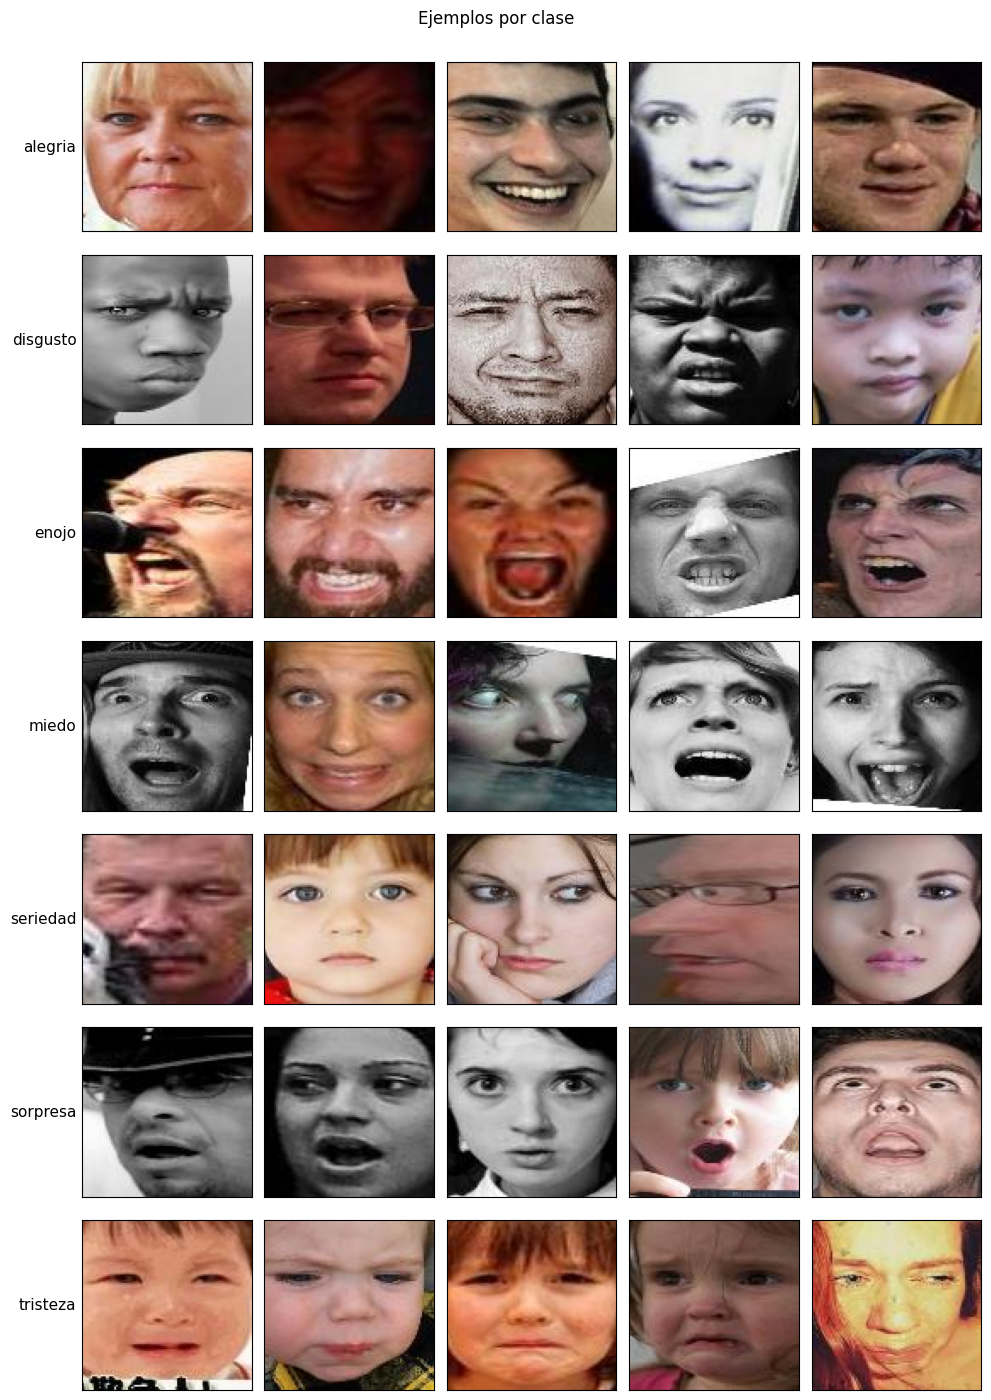

In [33]:
# Ejemplos por clase (una fila por emocion)
fig, axes = plt.subplots(len(class_names), 5, figsize=(10, 2 * len(class_names)))
for r, c in enumerate(class_names):
    d = os.path.join(DATASET_ROOT_TRAIN, c)
    files = [f for f in os.listdir(d) if not f.startswith(".")][:5]
    for k, f in enumerate(files):
        img = Image.open(os.path.join(d, f))
        axes[r, k].imshow(img)
        axes[r, k].set_xticks([])
        axes[r, k].set_yticks([])
        if k == 0:
            axes[r, k].set_ylabel(c, rotation=0, ha="right", va="center", fontsize=11)
plt.suptitle("Ejemplos por clase", y=1.0)
plt.tight_layout()
plt.show()

In [34]:
# Verificacion de tamano, modo de color y formato
sizes, modes, exts = collections.Counter(), collections.Counter(), collections.Counter()
for c in class_names:
    d = os.path.join(DATASET_ROOT_TRAIN, c)
    for f in [x for x in os.listdir(d) if not x.startswith(".")][:50]:
        exts[os.path.splitext(f)[1].lower()] += 1
        im = Image.open(os.path.join(d, f))
        sizes[im.size] += 1
        modes[im.mode] += 1
print("Tamanos:", sizes.most_common(5))
print("Modos de color:", modes.most_common())
print("Extensiones:", exts.most_common())

Tamanos: [((100, 100), 350)]
Modos de color: [('RGB', 350)]
Extensiones: [('.jpg', 350)]


### 1.2 Decisiones de preprocesamiento

A partir del EDA observamos que:

- Las imágenes son de **100×100 píxeles, en color (RGB) y formato `.jpg`**, todas del mismo tamaño y relación de aspecto (1:1).
- Existe un **fuerte desbalance de clases**: `alegria` tiene ~4.770 imágenes mientras que `miedo` apenas ~280 (relación cercana a **17:1**).

En base a esto elegimos (siendo criteriosos, solo lo pertinente para reconocimiento de emociones faciales):

| Técnica                 | Decisión                   | Justificación                                                                                                                                                                       |
| ----------------------- | -------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Escala de grises**    | Sí (1 canal)               | La emoción depende de la **geometría/textura del rostro** (cejas, boca, ojos), no del color.                                                                                        |
| **Resize**              | 100X100                    | Se mantienen en 100×100. Podria reducirse pero se perderia calidad.                                                                                                                 |
| **Relación de aspecto** | Se mantiene 1:1            | Ya son cuadradas: no hace falta recortar ni deformar.                                                                                                                               |
| **Normalización**       | media/desvío del train     | Centra las entradas y acelera/estabiliza el entrenamiento. Calculamos los valores reales sobre el set de train.                                                                     |
| **Data augmentation**   | Solo en train              | Combate el overfitting: flip horizontal (un rostro espejado sigue siendo válido), rotaciones leves, traslación/escala y jitter de brillo/contraste. **No** se aplica en validación. |
| **Desbalance**          | Pesos por clase en la loss | Penalizamos más los errores en clases minoritarias con `weight` en `CrossEntropyLoss`..                                                                                             |


In [35]:
IMG_SIZE = 100

# --- Media y desvio sobre el set de entrenamiento (en escala de grises) ---
tmp_tf = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
    ]
)
tmp_ds = datasets.ImageFolder(DATASET_ROOT_TRAIN, transform=tmp_tf)
tmp_loader = DataLoader(tmp_ds, batch_size=256, num_workers=0)
n_pix, suma, suma2 = 0, 0.0, 0.0
for x, _ in tmp_loader:
    n_pix += x.numel()
    suma += x.sum().item()
    suma2 += (x**2).sum().item()
MEAN = suma / n_pix
STD = (suma2 / n_pix - MEAN**2) ** 0.5
print("MEAN = {:.4f} | STD = {:.4f}".format(MEAN, STD))

MEAN = 0.4816 | STD = 0.2427


In [36]:
# --- Transformaciones ---
# Train: con data augmentation
train_transform = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=12),
        transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.1)),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[MEAN], std=[STD]),
    ]
)

# Validacion / inferencia: SOLO resize + normalizacion (sin augmentation)
eval_transform = transforms.Compose(
    [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[MEAN], std=[STD]),
    ]
)

In [37]:
BATCH_SIZE = 64

train_ds = datasets.ImageFolder(DATASET_ROOT_TRAIN, transform=train_transform)
val_ds = datasets.ImageFolder(DATASET_ROOT_VAL, transform=eval_transform)
class_names = train_ds.classes
print("Clases (idx -> nombre):", {i: n for i, n in enumerate(class_names)})

# Pesos para el optimizador. Para el fuerte desbalance del dataset
counts = np.array([cnt_train[c] for c in class_names], dtype=np.float32)
class_weights = counts.sum() / (len(counts) * counts)
class_weights_t = torch.tensor(class_weights, dtype=torch.float32, device=device)
print("Pesos por clase:", np.round(class_weights, 3))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("Batches -> train:", len(train_loader), "| val:", len(val_loader))

Clases (idx -> nombre): {0: 'alegria', 1: 'disgusto', 2: 'enojo', 3: 'miedo', 4: 'seriedad', 5: 'sorpresa', 6: 'tristeza'}
Pesos por clase: [0.367 2.445 2.487 6.238 0.695 1.359 0.884]
Batches -> train: 192 | val: 48


Shape del batch: (64, 1, 100, 100)


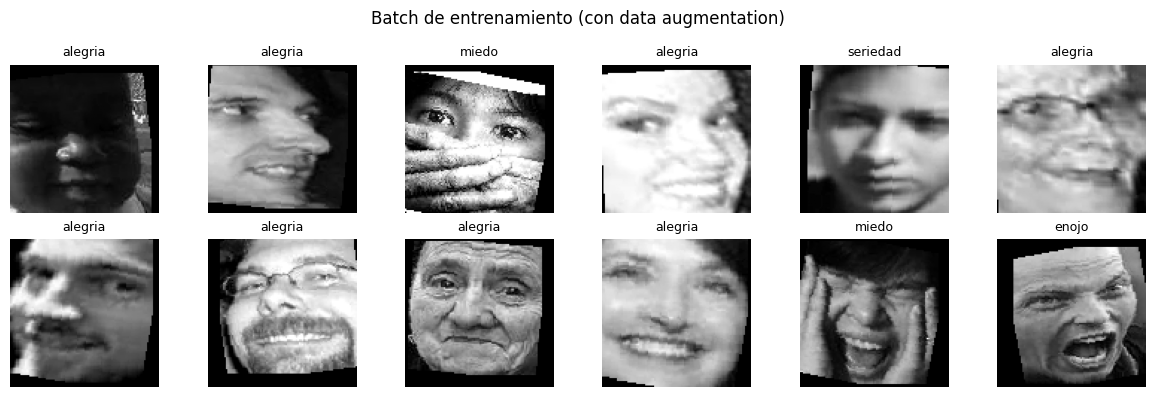

In [38]:
# Visualizar un batch ya transformado (desnormalizado para verlo)
x, y = next(iter(train_loader))
print("Shape del batch:", tuple(x.shape))
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i, ax in enumerate(axes.flat):
    img = x[i, 0].numpy() * STD + MEAN
    ax.imshow(img, cmap="gray")
    ax.axis("off")
    ax.set_title(class_names[y[i]], fontsize=9)
plt.suptitle("Batch de entrenamiento (con data augmentation)")
plt.tight_layout()
plt.show()

## 2. Construcción y entrenamiento del Modelo CNN (3.5 puntos)

- Construir una red neuronal convolucional con PyTorch, **sin usar modelos pre-entrenados**.
- Analizar correctamente qué funciones de activación se deben usar en cada etapa de la red, el learning rate a utilizar, la función de costo y el optimizador.
- Cosas como el número de capas, neuronas, número y tamaño de los kernels, entre otros, queda a criterio de ustedes, pero deben estar justificadas.


### 2.1 Arquitectura de la red

Construimos una **CNN desde cero** (sin modelos pre-entrenados). Vamos extrayendo características cada vez más abstractas con bloques convolucionales y luego clasificamos con capas densas.

**Diseño (3 bloques convolucionales + clasificador):**

- Cada **bloque** = `Conv 3×3 -> BatchNorm -> ReLU -> Conv 3×3 -> BatchNorm -> ReLU -> MaxPool 2×2`.
  - **Kernels 3×3**: estándar moderno; apilar dos 3×3 equivale a un campo receptivo 5×5 con menos parámetros.
  - **BatchNorm**: estabiliza/acelera el entrenamiento y regulariza levemente.
  - **ReLU**: no linealidad eficiente que evita el desvanecimiento del gradiente.
  - **MaxPool 2×2**: reduce la resolución a la mitad y aporta invarianza a pequeñas traslaciones.
- La cantidad de filtros **crece** (32 -> 64 -> 128): a mayor profundidad, patrones más complejos.
- El **clasificador** aplica primero `AdaptiveAvgPool((4,4))` (Global Average Pooling), luego aplana (2048) y usa `Dropout(0.5)` (regularización fuerte) + densa de 256 + salida de 7 logits.
- **La salida NO lleva activación**: `CrossEntropyLoss` ya aplica internamente `LogSoftmax`. Poner softmax acá sería un error.

Mapa de tamaños con entrada **100×100**: `100×100 -> 50×50 -> 25×25 -> 12×12` (un MaxPool por bloque). Luego el `AdaptiveAvgPool((4,4))` lo reduce a `128×4×4 = 2048` features, que son las que entran a la parte densa. _Gracias al pooling adaptativo, la red funciona con cualquier `IMG_SIZE` sin recalcular esta capa._

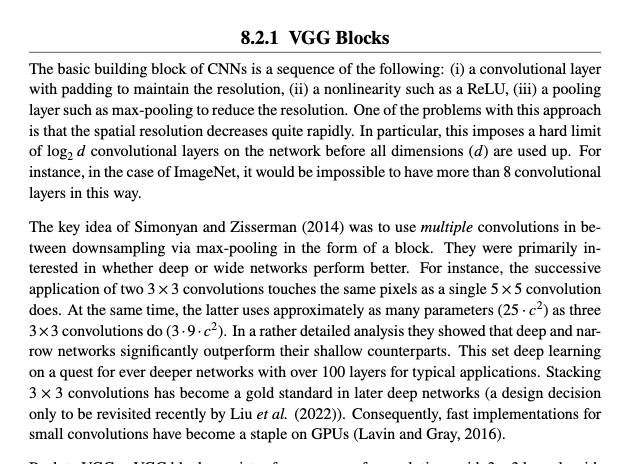

La arquitectura elegida esta inspirada en VGG el cual tiene las siguientes características:

- Kernels pequeños de 3x3 en todas las convoluciones
- Apilar varias convoluciones antes de un pool. VGG hace un pool al final del bloque para no reducir tan rapido la resolucion
- Duplicacion de canales despues de cada pool
- MaxPool 2x2

Cabe mencionar que no es exactamente una VGG, sino que usa bloques convolucionales estilo VGG con algunos cambios, por ejemplo, VGG original del paper no usa BatchNorm.

Algunos cambios en esta red:

- BatchNorm: Fue despues que VGG
- AdaptiveAvgPool: Idea posterior a VGG que es justamente para evitar las capas densas enormes con el que VGG termina, ya que pues al final depende del problema especifico a resolver.

Se realizó inspirado en VGG ya que inició el agrupado de convoluciones que según el libro fue un patrón que estuvo sin cambiarse por casi una decada con algunos cambios en medio. `8.2.2 VGG Network - Dive into Deep Learning`


In [ ]:
class EmotionCNN(nn.Module):
    # CNN para clasificar 7 emociones. Entrada: 1 canal (gris) de IMG_SIZE x IMG_SIZE.
    def __init__(self, n_classes=7, in_ch=1, p_drop=0.5):
        super().__init__()

        def conv_block(i, o):
            return nn.Sequential(
                nn.Conv2d(
                    i, o, kernel_size=3, padding=1
                ),  ## padding 1 para que el kernel no reduzca el tamaño de la imagen
                nn.BatchNorm2d(o),
                nn.ReLU(inplace=True),
                nn.Conv2d(o, o, kernel_size=3, padding=1),
                nn.BatchNorm2d(o),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            conv_block(in_ch, 32),
            conv_block(32, 64),
            conv_block(64, 128),
        )
        # AdaptiveAvgPool2d fija la salida espacial en 4x4 sin importar el tamaño de
        # entrada (64x64, 100x100, etc.), por lo que el clasificador NO depende de IMG_SIZE.
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Dropout(p_drop),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(256, n_classes),  # salida = logits (sin softmax)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = EmotionCNN(n_classes=len(class_names)).to(device)
print(model)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("\nParametros entrenables: {:,}".format(n_params))
with torch.no_grad():
    test_out = model(torch.randn(2, 1, IMG_SIZE, IMG_SIZE).to(device))
print("Salida de prueba:", tuple(test_out.shape))

EmotionCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace

### 2.2 Función de costo, optimizador y learning rate

- **Función de costo:** `CrossEntropyLoss`, estándar para **clasificación multiclase**. Le pasamos `weight` con los pesos por clase para compensar el desbalance.
- **Optimizador:** `Adam`, converge rápido y requiere poco ajuste manual. Agregamos `weight_decay=1e-4` (regularización L2).
- **Learning rate:** `1e-3` (valor inicial habitual para Adam). Usamos un scheduler `ReduceLROnPlateau` que baja el lr a la mitad cuando el F1 de validación se estanca, para afinar al final.
- **Early stopping:** guardamos el modelo con mejor **F1-macro de validación** y cortamos si no mejora en 8 épocas.


In [40]:
criterion = nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)
EPOCHS = 40
PATIENCE = 8  # early stopping

### 2.3 Entrenamiento


In [41]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            if train:
                optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            all_preds.append(out.argmax(1).detach().cpu().numpy())
            all_labels.append(y.cpu().numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, acc, f1


history = {
    k: []
    for k in ["train_loss", "val_loss", "train_acc", "val_acc", "train_f1", "val_f1"]
}
best_f1, best_state, epochs_no_improve = 0.0, None, 0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc, tr_f1 = run_epoch(train_loader, train=True)
    va_loss, va_acc, va_f1 = run_epoch(val_loader, train=False)
    scheduler.step(va_f1)
    for k, v in zip(history, [tr_loss, va_loss, tr_acc, va_acc, tr_f1, va_f1]):
        history[k].append(v)
    print(
        "Epoca {:02d}/{} | loss {:.3f}/{:.3f} | acc {:.3f}/{:.3f} | f1 {:.3f}/{:.3f} | {:.0f}s".format(
            epoch,
            EPOCHS,
            tr_loss,
            va_loss,
            tr_acc,
            va_acc,
            tr_f1,
            va_f1,
            time.time() - t0,
        )
    )
    if va_f1 > best_f1:
        best_f1, best_state, epochs_no_improve = (
            va_f1,
            copy.deepcopy(model.state_dict()),
            0,
        )
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(
                "Early stopping en epoca {} (mejor F1 val = {:.3f})".format(
                    epoch, best_f1
                )
            )
            break

model.load_state_dict(best_state)
torch.save(best_state, "mejor_modelo.pth")
print("\nMejor F1-macro en validacion: {:.4f}".format(best_f1))

Epoca 01/40 | loss 1.922/1.885 | acc 0.227/0.313 | f1 0.168/0.166 | 14s
Epoca 02/40 | loss 1.867/1.771 | acc 0.238/0.361 | f1 0.185/0.239 | 12s
Epoca 03/40 | loss 1.842/1.793 | acc 0.261/0.314 | f1 0.207/0.231 | 12s
Epoca 04/40 | loss 1.796/1.714 | acc 0.314/0.341 | f1 0.237/0.230 | 12s
Epoca 05/40 | loss 1.743/1.523 | acc 0.351/0.450 | f1 0.268/0.329 | 12s
Epoca 06/40 | loss 1.693/1.532 | acc 0.373/0.426 | f1 0.290/0.337 | 12s
Epoca 07/40 | loss 1.664/1.417 | acc 0.380/0.507 | f1 0.304/0.444 | 12s
Epoca 08/40 | loss 1.622/1.385 | acc 0.418/0.508 | f1 0.333/0.434 | 13s
Epoca 09/40 | loss 1.583/1.295 | acc 0.426/0.539 | f1 0.342/0.443 | 12s
Epoca 10/40 | loss 1.527/1.272 | acc 0.450/0.554 | f1 0.371/0.490 | 12s
Epoca 11/40 | loss 1.507/1.316 | acc 0.467/0.533 | f1 0.378/0.458 | 12s
Epoca 12/40 | loss 1.473/1.190 | acc 0.476/0.556 | f1 0.390/0.502 | 12s
Epoca 13/40 | loss 1.443/1.449 | acc 0.492/0.468 | f1 0.399/0.402 | 12s
Epoca 14/40 | loss 1.419/1.165 | acc 0.504/0.584 | f1 0.414/0.46

## 3. Evaluación del Modelo (2.5 puntos)

El modelo entrenado debe ser evaluado utilizando las siguientes métricas:

- **Accuracy**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **F1 Score Macro**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **Costo (Loss)**:
  - Mostrar una gráfica de evolución del costo por época para entrenamiento y validación.

- **Classification report**
  - Mostrar la precisión, recall y F1 score por cada clase usando `classification_report`

- **Matriz de confusión**:
  - Mostrar la matriz de confusión absoluta (valores enteros).
  - Mostrar la matriz de confusión normalizada (valores entre 0 y 1 por fila).

Se recomienda utilizar `scikit-learn` para calcular métricas como accuracy, F1 score, el Classification report y las matrices de confusión. Las visualizaciones pueden realizarse con `matplotlib` o `seaborn`.


## Evaluación

Evaluamos el **mejor modelo** (el de mayor F1-macro en validación) con todas las métricas pedidas.


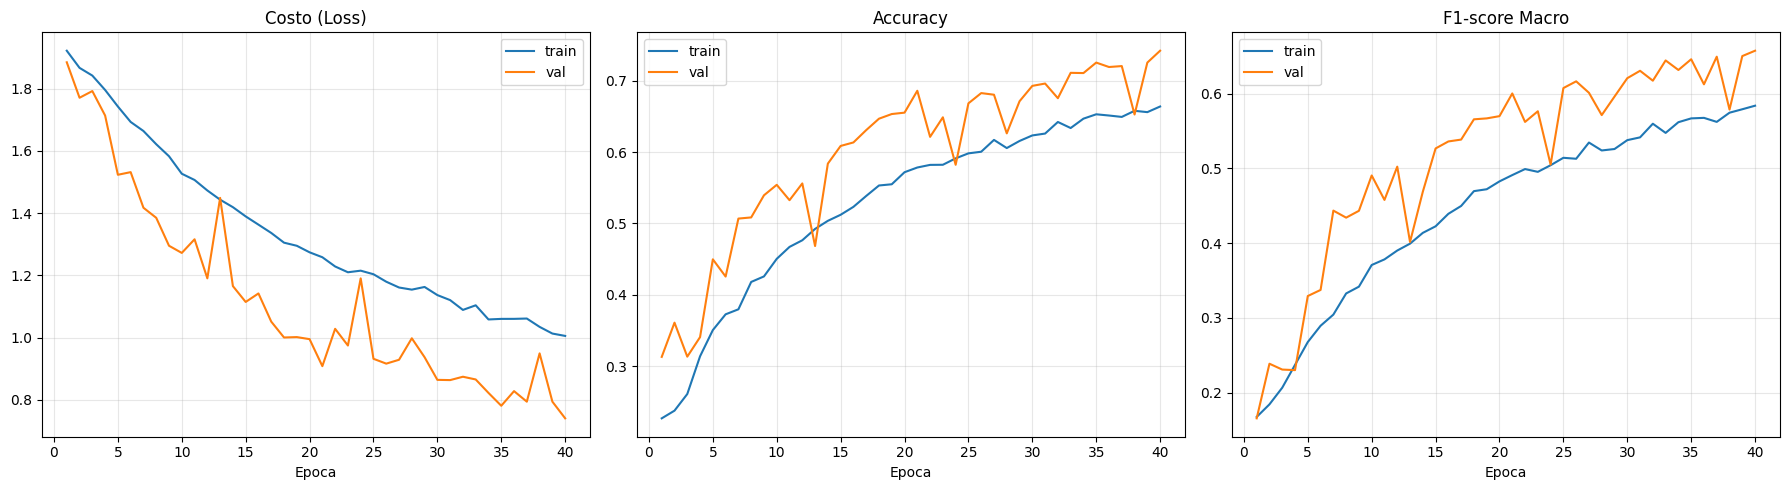

In [42]:
# Curvas por epoca: loss, accuracy y F1-macro (train vs val)
ep = range(1, len(history["train_loss"]) + 1)
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].plot(ep, history["train_loss"], label="train")
ax[0].plot(ep, history["val_loss"], label="val")
ax[0].set_title("Costo (Loss)")
ax[0].set_xlabel("Epoca")
ax[0].legend()
ax[0].grid(alpha=0.3)
ax[1].plot(ep, history["train_acc"], label="train")
ax[1].plot(ep, history["val_acc"], label="val")
ax[1].set_title("Accuracy")
ax[1].set_xlabel("Epoca")
ax[1].legend()
ax[1].grid(alpha=0.3)
ax[2].plot(ep, history["train_f1"], label="train")
ax[2].plot(ep, history["val_f1"], label="val")
ax[2].set_title("F1-score Macro")
ax[2].set_xlabel("Epoca")
ax[2].legend()
ax[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
# Predicciones finales sobre validacion con el mejor modelo
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in val_loader:
        out = model(x.to(device))
        y_pred.append(out.argmax(1).cpu().numpy())
        y_true.append(y.numpy())
y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

print("Accuracy validacion :", round(accuracy_score(y_true, y_pred), 4))
print("F1-macro validacion :", round(f1_score(y_true, y_pred, average="macro"), 4))
print("\nClassification report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

Accuracy validacion : 0.7419
F1-macro validacion : 0.6573

Classification report:

              precision    recall  f1-score   support

     alegria      0.919     0.836     0.876      1185
    disgusto      0.278     0.512     0.360       160
       enojo      0.880     0.543     0.672       162
       miedo      0.452     0.635     0.528        74
    seriedad      0.703     0.715     0.709       680
    sorpresa      0.697     0.888     0.781       329
    tristeza      0.761     0.607     0.675       478

    accuracy                          0.742      3068
   macro avg      0.670     0.677     0.657      3068
weighted avg      0.776     0.742     0.751      3068



Esto es buen resultado para este problema, dado el desbalance, cantidad de datos y arquitectura:

- Buen rendimiento en alegria, sorpresa y seriedad
- En el resto hay buena precision pero un recall bajo.


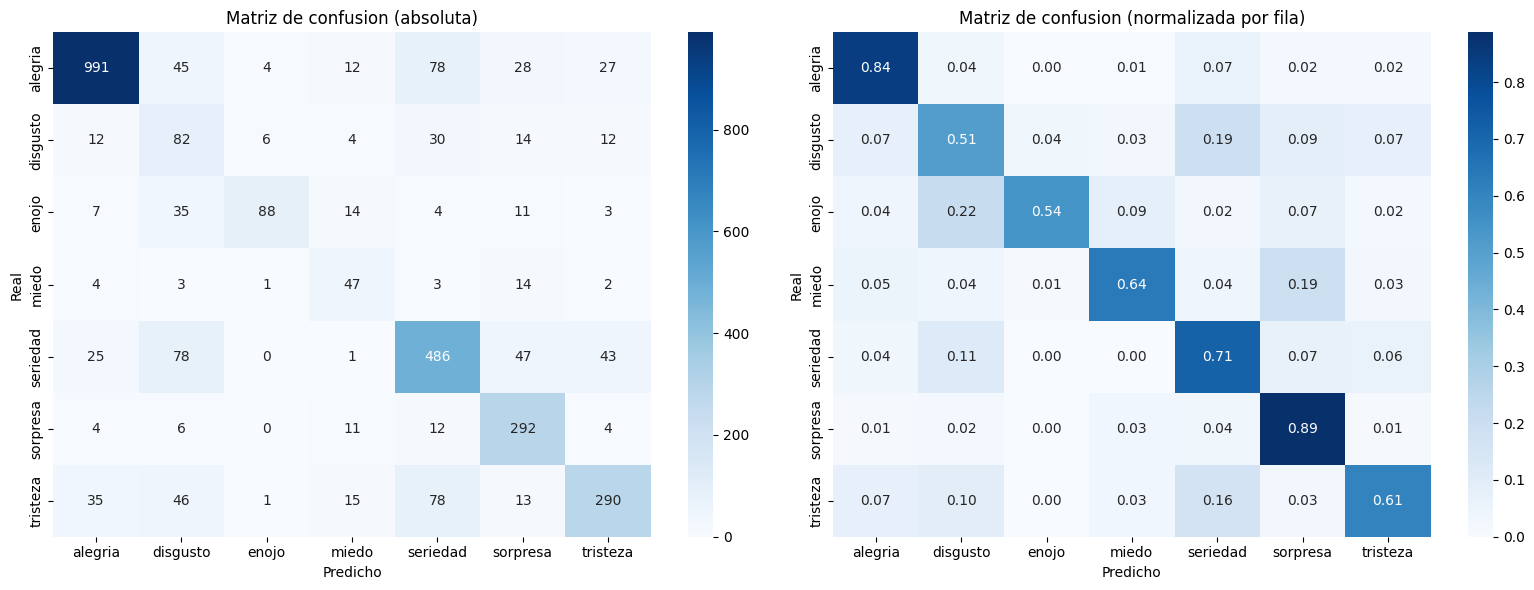

In [44]:
# Matrices de confusion: absoluta y normalizada por fila
cm = confusion_matrix(y_true, y_pred)
cm_norm = confusion_matrix(y_true, y_pred, normalize="true")
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax[0],
)
ax[0].set_title("Matriz de confusion (absoluta)")
ax[0].set_xlabel("Predicho")
ax[0].set_ylabel("Real")
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax[1],
)
ax[1].set_title("Matriz de confusion (normalizada por fila)")
ax[1].set_xlabel("Predicho")
ax[1].set_ylabel("Real")
plt.tight_layout()
plt.show()

### Observaciones de la evaluación

El modelo generaliza bien (74% de accuracy / 0.66 F1-macro) y se observa que dominan las emociones expresivas (alegria, sorpresa) que son de las que hay mas imagenes. Debido a las tecnicas de desbalance implementadas se obtuvo un buen rendimiento en las clases minoritarias aunque a costa de sobre predecirlas (baja precisión en disgusto/miedo).


## 4. Prueba de Imágenes Nuevas (1 punto)

Subir al menos 12 imágenes personales de cualquier ratio o relación de aspecto (pueden usar fotos del rostro de ustedes, rostros de personas generadas por IA o imágenes stock de internet), que no formen parte del dataset de entrenamiento ni de validación. Tampoco vale usar imágenes de otro dataset, deben ser imágenes sueltas.

- Debe haber al menos una imagen para cada emoción.

- Aplicar el mismo pre-procesamiento que se usó para el dataset de validation durante el entrenamiento del modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:
  - La imagen original
  - La imagen pre-procesada (mismas transformaciones que durante el entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase ganadora inferida por el modelo

- Redactar conclusiones preliminares


## Resolución

**Instrucciones:**

1. Ejecutá la celda que crea las carpetas en `imagenes_nuevas/<emocion>/` (carpeta local junto al notebook).
2. Subí cada imagen a la carpeta de su emoción (al menos **1 por emoción**, **≥12 en total**). Podés arrastrarlas desde el panel de archivos de Colab o usar el bloque de subida interactiva comentado.
3. Ejecutá las celdas siguientes para ver original + preprocesada + scores + clase ganadora.


In [45]:
# Mapa de nombres lindos para mostrar
DISPLAY = {
    "alegria": "Alegria",
    "disgusto": "Disgusto",
    "enojo": "Enojo",
    "miedo": "Miedo",
    "seriedad": "Seriedad",
    "sorpresa": "Sorpresa",
    "tristeza": "Tristeza",
}

BASE_NUEVAS = "imagenes_nuevas"
for c in class_names:
    os.makedirs(os.path.join(BASE_NUEVAS, c), exist_ok=True)
print("Carpetas creadas en", BASE_NUEVAS)
print(
    "Subi tus imagenes a la carpeta de la emocion correspondiente (>=1 por emocion, >=12 en total)."
)

# --- Subida interactiva opcional (descomentar) ---
# from google.colab import files
# for c in class_names:
#     print('Subi imagen(es) para:', c)
#     up = files.upload()
#     for fn in up:
#         os.rename(fn, os.path.join(BASE_NUEVAS, c, fn))

Carpetas creadas en imagenes_nuevas
Subi tus imagenes a la carpeta de la emocion correspondiente (>=1 por emocion, >=12 en total).


In [46]:
def cargar_imagenes(base):
    # Devuelve lista de (ruta, etiqueta_esperada)
    items = []
    for c in class_names:
        d = os.path.join(base, c)
        if not os.path.isdir(d):
            continue
        for f in sorted(os.listdir(d)):
            if f.startswith("."):
                continue
            items.append((os.path.join(d, f), c))
    return items


def predecir(pil_img):
    # Aplica eval_transform (mismo preprocesamiento que validacion) y devuelve (probs, idx_ganador)
    x = eval_transform(pil_img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        probs = F.softmax(model(x), dim=1).cpu().numpy()[0]
    return probs, int(probs.argmax())


def mostrar_prediccion(pil_img, probs, idx_pred, esperada=None, recorte=None):
    ncols = 4 if recorte is not None else 3
    fig, ax = plt.subplots(1, ncols, figsize=(4 * ncols, 4))
    col = 0
    ax[col].imshow(pil_img)
    ax[col].set_title("Original")
    ax[col].axis("off")
    col += 1
    if recorte is not None:
        ax[col].imshow(recorte)
        ax[col].set_title("Recorte (rostro)")
        ax[col].axis("off")
        col += 1
    t = eval_transform(pil_img)
    img = t[0].numpy() * STD + MEAN
    ax[col].imshow(img, cmap="gray")
    ax[col].set_title("Preprocesada (64x64)")
    ax[col].axis("off")
    col += 1
    colores = [
        "green" if i == idx_pred else "steelblue" for i in range(len(class_names))
    ]
    ax[col].barh([DISPLAY[c] for c in class_names], probs, color=colores)
    ax[col].set_xlim(0, 1)
    ax[col].invert_yaxis()
    ax[col].set_xlabel("Probabilidad")
    titulo = (
        "Predicho: "
        + DISPLAY[class_names[idx_pred]]
        + " ("
        + str(round(probs[idx_pred] * 100, 1))
        + "%)"
    )
    if esperada is not None:
        ok = "OK" if class_names[idx_pred] == esperada else "X"
        titulo += "  | Esperado: " + DISPLAY[esperada] + " [" + ok + "]"
    ax[col].set_title(titulo, fontsize=9)
    plt.tight_layout()
    plt.show()

In [47]:
# Inferencia sobre las imagenes nuevas (sin recorte de rostro)
items = cargar_imagenes(BASE_NUEVAS)
print("Se encontraron", len(items), "imagenes.")
pred4 = {}
aciertos4 = 0
for ruta, esperada in items:
    pil = Image.open(ruta).convert("RGB")
    probs, idx = predecir(pil)
    pred4[ruta] = (esperada, class_names[idx], float(probs[idx]))
    aciertos4 += int(class_names[idx] == esperada)
    mostrar_prediccion(pil, probs, idx, esperada=esperada)
if items:
    print("\nAciertos Punto 4: {}/{}".format(aciertos4, len(items)))

Se encontraron 0 imagenes.


### Conclusiones preliminares (Punto 4)

> ⚠️ Redactá en base a tus resultados.

A comentar:

- ¿En qué emociones acertó y en cuáles falló el modelo?
- Las imágenes nuevas suelen tener **fondo, iluminación y encuadre distintos** al dataset (que son primeros planos del rostro). Si la cara ocupa poca parte de la imagen, el resize a 64×64 la **empequeñece** y el modelo pierde detalle -> esto motiva el recorte de rostro del Punto 5.
- Las emociones más expresivas (alegría, sorpresa) suelen reconocerse mejor que las sutiles (seriedad, disgusto).


## 5. Prueba de Imágenes Nuevas con Pre-procesamiento Adicional (1 punto)

Las 12 imágenes del punto 4, ahora serán pasadas y recortadas por un algoritmo de detección de rostros. Usen el siguiente código para realizar un pre-procesamiento inicial de la imagen y ya luego aplican el pre-procesamiento que usaron al momento de entrenar el modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:
  - La imagen original
  - La imagen recortada por el algoritmo
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase esperada
  - La clase ganadora inferida por el modelo

- Analizar los casos en los que el modelo se equivoca e intentar identificar posibles causas, tales como:
  - Similitudes entre emociones.
  - Mezcla de 2 o más emociones en una misma expresión.

- Comparar los resultados con el punto 4 y redactar conclusiones finales.

**IMPORTANTE:** Ajusten los parámetros `scaleFactor`, `minNeighbors` y `minSize` según convenga para que la detección de rostros sea más efectiva y logre detectar rostros en sus 12 imágenes. No se queden necesariamente con los valores por defecto.


In [48]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

image_path = ""

image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)
faces = face_cascade.detectMultiScale(
    gray, scaleFactor=1.1, minNeighbors=6, minSize=(30, 30)
)

image_with_box = image.copy()
for x, y, w, h in faces:
    cv2.rectangle(image_with_box, (x, y), (x + w, y + h), (0, 255, 0), 2)

cropped_face_rgb = None
if len(faces) > 0:
    x, y, w, h = faces[0]
    center_x, center_y = x + w // 2, y + h // 2
    side = max(w, h)
    half_side = side // 2

    x1 = max(center_x - half_side, 0)
    y1 = max(center_y - half_side, 0)
    x2 = min(center_x + half_side, image.shape[1])
    y2 = min(center_y + half_side, image.shape[0])

    cropped_face = image[y1:y2, x1:x2]
    cropped_face_rgb = cv2.cvtColor(cropped_face, cv2.COLOR_BGR2RGB)

image_with_box_rgb = cv2.cvtColor(image_with_box, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image_with_box_rgb)
ax[0].set_title("Detección")
ax[0].axis("off")

if cropped_face_rgb is not None:
    ax[1].imshow(cropped_face_rgb)
    ax[1].set_title("Rostro recortado (relación aspecto 1:1)")
    ax[1].axis("off")
else:
    ax[1].text(
        0.5,
        0.5,
        "No se detectó rostro",
        horizontalalignment="center",
        verticalalignment="center",
    )
    ax[1].axis("off")

plt.tight_layout()
plt.show()

[ WARN:0@11772.163] global loadsave.cpp:278 findDecoder imread_(''): can't open/read file: check file path/integrity


error: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


## Resolución

Reutilizamos el detector de rostros (**Haar Cascade**) para **recortar el rostro** de cada imagen y recién después aplicamos el **mismo preprocesamiento** del entrenamiento (`eval_transform`). Así el rostro ocupa todo el cuadro, parecido a las imágenes del dataset.

Envolvemos el código provisto en una función `detectar_y_recortar`. **Ajustá `scaleFactor`, `minNeighbors` y `minSize`** si alguna imagen no detecta rostro.


In [ ]:
import cv2

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)


def detectar_y_recortar(image_path, scaleFactor=1.1, minNeighbors=6, minSize=(40, 40)):
    # Detecta el rostro y devuelve el recorte 1:1 en RGB (o None si no detecta)
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=scaleFactor, minNeighbors=minNeighbors, minSize=minSize
    )
    if len(faces) == 0:
        return None
    x, y, w, h = faces[0]
    cx, cy = x + w // 2, y + h // 2
    side = max(w, h)
    half = side // 2
    x1, y1 = max(cx - half, 0), max(cy - half, 0)
    x2, y2 = min(cx + half, image.shape[1]), min(cy + half, image.shape[0])
    crop = image[y1:y2, x1:x2]
    return cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

In [ ]:
# Inferencia con recorte de rostro previo
pred5 = {}
aciertos5, total5 = 0, 0
for ruta, esperada in items:
    pil = Image.open(ruta).convert("RGB")
    recorte = detectar_y_recortar(
        ruta, scaleFactor=1.1, minNeighbors=6, minSize=(40, 40)
    )
    if recorte is None:
        print(
            "[!] No se detecto rostro en",
            os.path.basename(ruta),
            "-> ajusta scaleFactor/minNeighbors/minSize",
        )
        continue
    recorte_pil = Image.fromarray(recorte)
    probs, idx = predecir(recorte_pil)
    total5 += 1
    aciertos5 += int(class_names[idx] == esperada)
    pred5[ruta] = (esperada, class_names[idx], float(probs[idx]))
    mostrar_prediccion(pil, probs, idx, esperada=esperada, recorte=recorte)
if total5:
    print("\nAciertos Punto 5: {}/{} (rostros detectados)".format(aciertos5, total5))

In [ ]:
# Tabla comparativa Punto 4 vs Punto 5
print("{:30s} {:10s} {:12s} {:12s}".format("Imagen", "Esperada", "Pred P4", "Pred P5"))
print("-" * 66)
for ruta, esperada in items:
    p4 = pred4.get(ruta, (None, "-", 0))[1]
    p5 = pred5.get(ruta, (None, "sin rostro", 0))[1]
    print(
        "{:30s} {:10s} {:12s} {:12s}".format(
            os.path.basename(ruta)[:28], esperada, p4, p5
        )
    )

### Conclusiones finales (Punto 5)

> ⚠️ Redactá en base a tus resultados y a la tabla comparativa.

**Comparación Punto 4 vs Punto 5:**

- Al recortar el rostro, el modelo recibe una entrada mucho más parecida a la de su entrenamiento (cara centrada y a escala). En general esto **mejora** las predicciones respecto al Punto 4, sobre todo en fotos donde antes la cara era pequeña respecto al fondo.

**Análisis de errores** (casos donde el modelo se equivoca):

- **Similitud entre emociones:** miedo/sorpresa, enojo/disgusto y seriedad/tristeza comparten rasgos faciales y se confunden con facilidad.
- **Mezcla de emociones:** una misma expresión puede tener componentes de dos emociones (p. ej. una sonrisa nerviosa entre alegría y miedo).
- **Limitaciones del detector:** si Haar no detecta el rostro (perfil, oclusiones, baja luz) o recorta de más/menos, la predicción se degrada.
- **Desbalance:** las clases con pocas muestras (miedo, disgusto, enojo) tienen peor desempeño y arrastran el F1-macro.

**Conclusión global:** el recorte de rostro como preprocesamiento adicional reduce la brecha entre las imágenes nuevas y el dominio de entrenamiento, mejorando la robustez del clasificador.
